In [19]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [15]:
df_final = pd.read_csv("dataset/enriched_dataset.csv", sep=";")

In [16]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9266 entries, 0 to 9265
Data columns (total 40 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   datetime                                    9266 non-null   object 
 1   Identifiant arc                             9266 non-null   int64  
 2   Libelle                                     9266 non-null   object 
 3   debit_horaire                               8703 non-null   float64
 4   taux_occupation                             8644 non-null   float64
 5   Etat trafic                                 9266 non-null   object 
 6   Identifiant noeud amont                     9266 non-null   int64  
 7   noeud_amont                                 9266 non-null   object 
 8   Identifiant noeud aval                      9266 non-null   int64  
 9   noeud_aval                                  9266 non-null   object 
 10  Etat arc    

Colonne datetime détectée : datetime

MODÈLES NAÏFS - PRÉDICTION AVEC SPLIT 80/20

Dataset total : 9266 points
Train : 7412 points (80%)
Test : 1854 points (20%)

Période d'entraînement : 2024-09-01 03:00:00+00:00 à 2025-08-13 16:00:00+00:00
Période de test : 2025-08-13 17:00:00+00:00 à 2025-10-29 23:00:00+00:00

ANALYSE POUR : DEBIT_HORAIRE

📊 Création des prédictions naïves...
✓ Modèles créés : 2
  - Lag 1 Semaine
  - Moyenne Heure Jour

RÉSULTATS - RMSE
            Modèle       RMSE  N échantillons
Moyenne Heure Jour 131.485606            1773
     Lag 1 Semaine 204.799849            1417

🏆 MEILLEUR MODÈLE : Moyenne Heure Jour
   RMSE : 131.49

📈 Génération des graphiques...


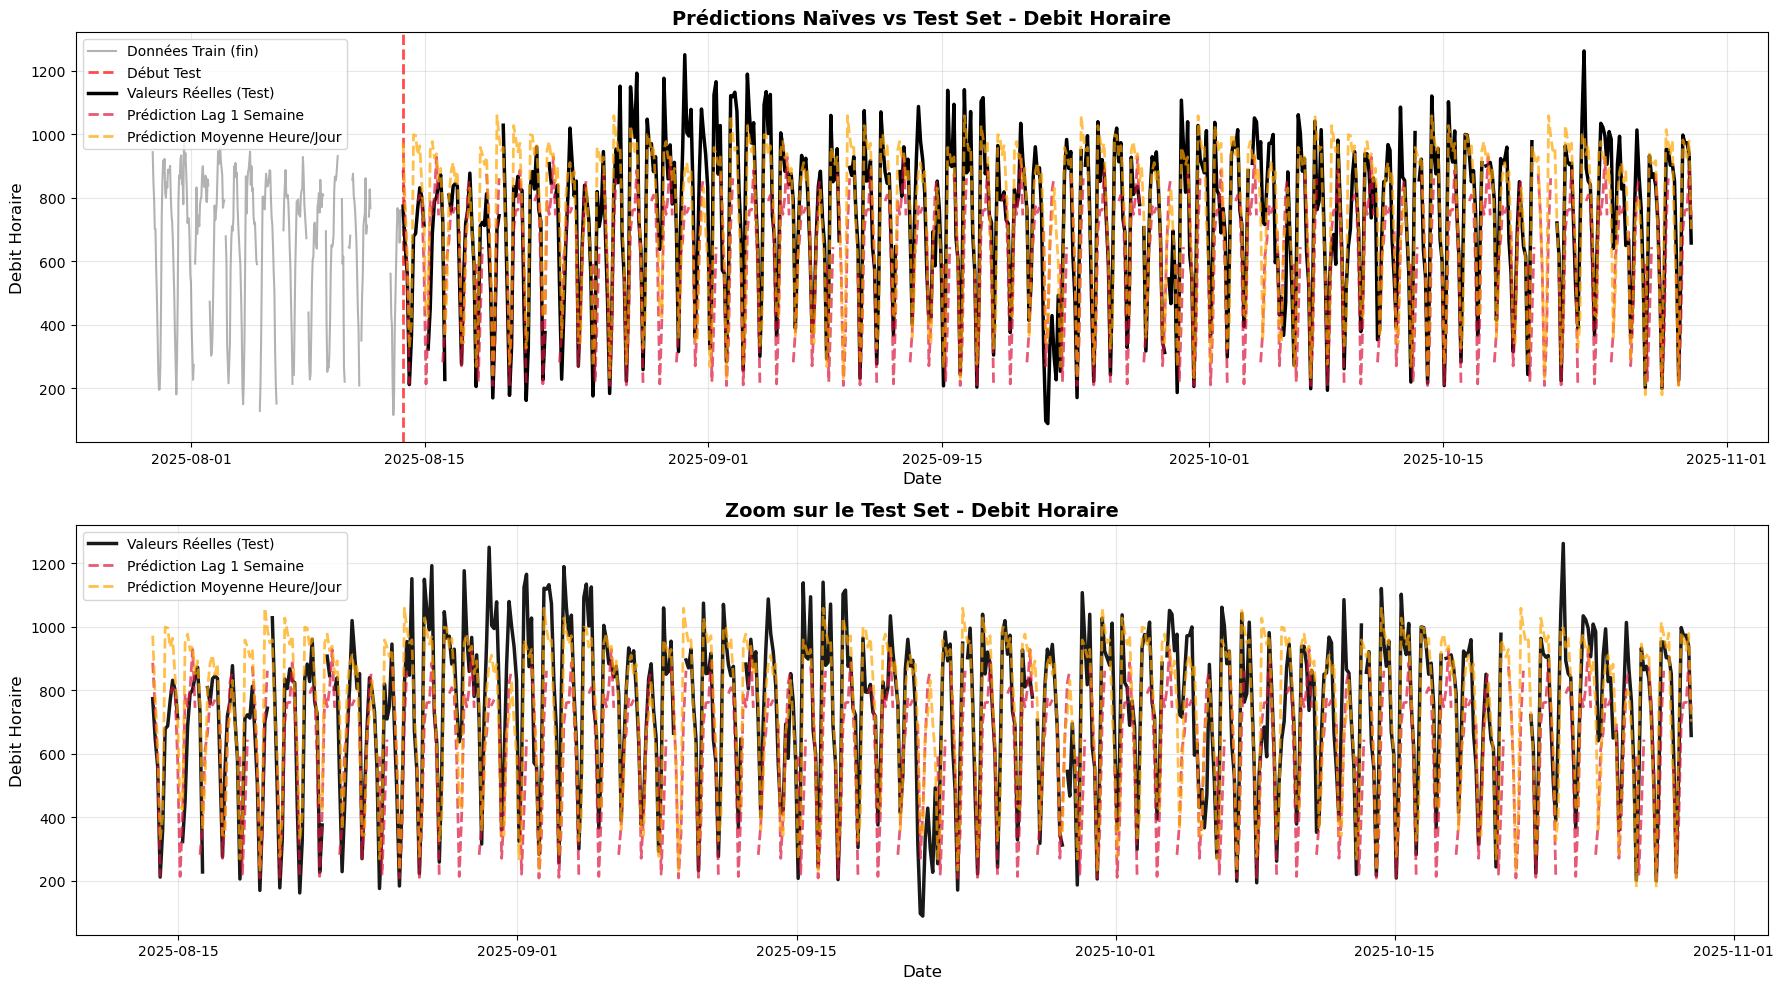

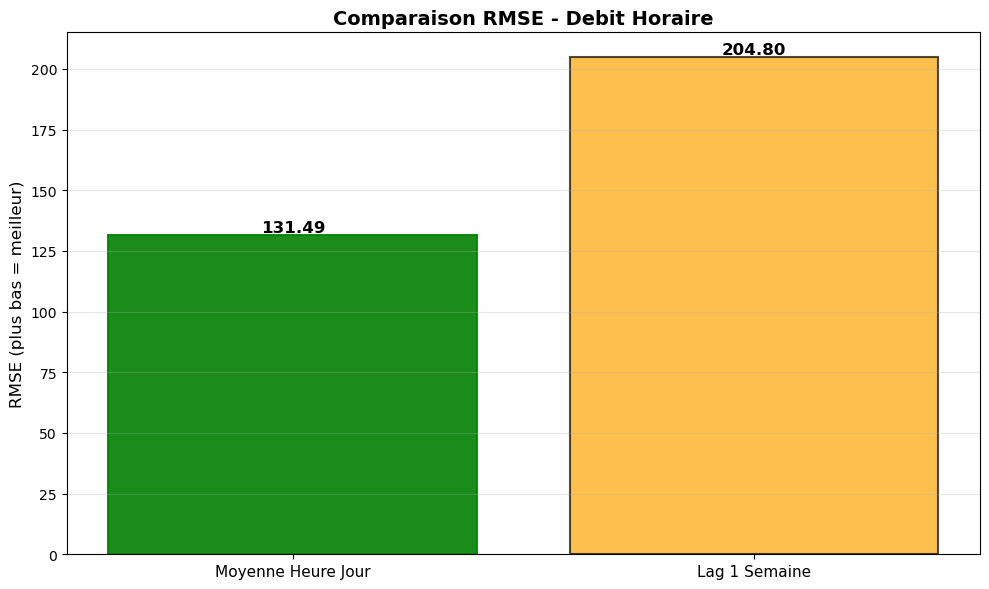


ANALYSE POUR : TAUX_OCCUPATION

📊 Création des prédictions naïves...
✓ Modèles créés : 2
  - Lag 1 Semaine
  - Moyenne Heure Jour

RÉSULTATS - RMSE
            Modèle     RMSE  N échantillons
Moyenne Heure Jour 6.572763            1773
     Lag 1 Semaine 8.250055            1417

🏆 MEILLEUR MODÈLE : Moyenne Heure Jour
   RMSE : 6.57

📈 Génération des graphiques...


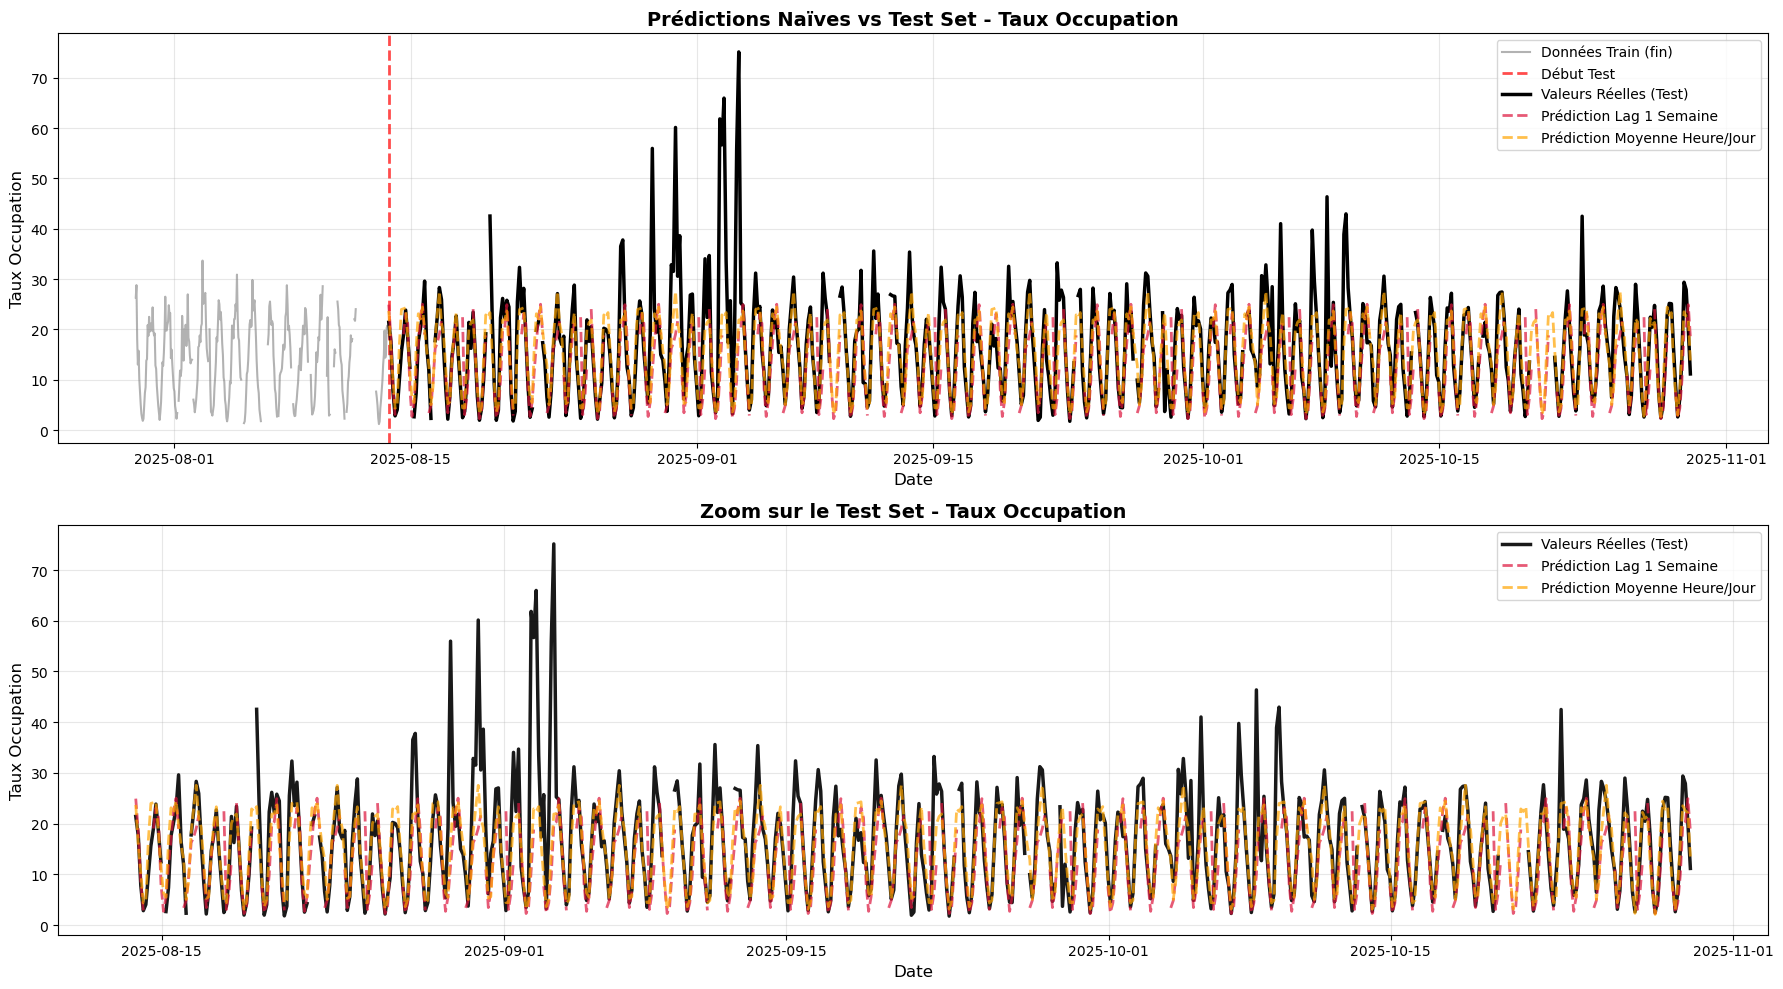

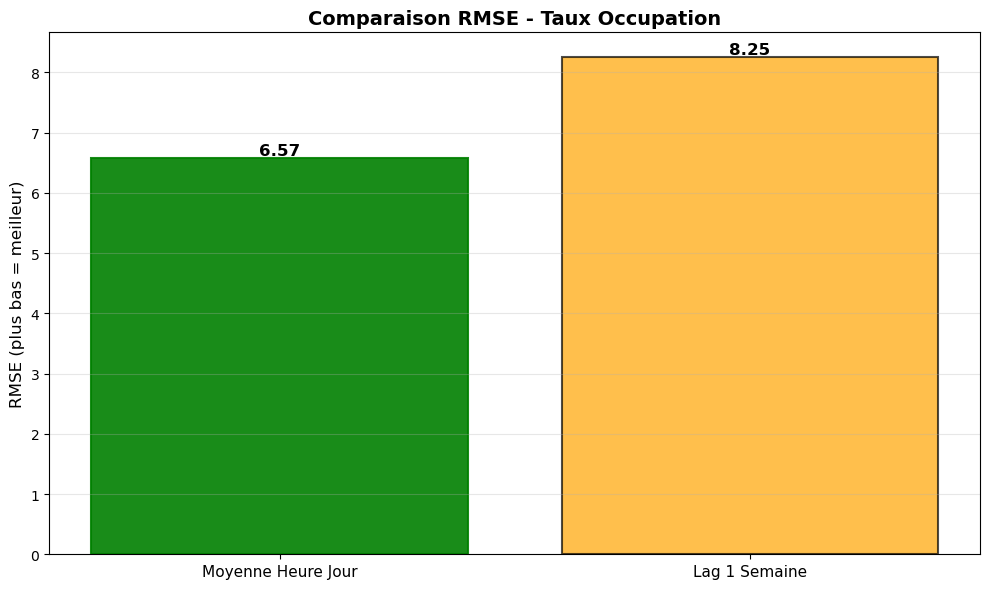


✓ ANALYSE TERMINÉE


In [21]:
# --- 1. SPLIT TEMPOREL 80/20 ---

def temporal_split(df, train_ratio=0.8):
    """
    Split temporel simple : 80% train, 20% test
    """
    n = len(df)
    train_end = int(n * train_ratio)
    
    train_set = df.iloc[:train_end].copy()
    test_set = df.iloc[train_end:].copy()
    
    print(f"\nDataset total : {n} points")
    print(f"Train : {len(train_set)} points ({train_ratio*100:.0f}%)")
    print(f"Test : {len(test_set)} points ({(1-train_ratio)*100:.0f}%)")
    
    if isinstance(df.index, pd.DatetimeIndex):
        print(f"\nPériode d'entraînement : {train_set.index[0]} à {train_set.index[-1]}")
        print(f"Période de test : {test_set.index[0]} à {test_set.index[-1]}")
    
    return train_set, test_set


# --- 2. MODÈLES NAÏFS ---

def create_naive_predictions(train_set, test_set, target_col):
    """
    Crée les prédictions naïves à partir du train set uniquement
    
    Deux stratégies :
    1. Lag 1 semaine (168h) : répète les valeurs de la dernière semaine du train
    2. Moyenne par heure/jour : moyenne de chaque heure/jour de la semaine du train
    """
    predictions = pd.DataFrame(index=test_set.index)
    
    # Vérifier si on a un index datetime
    has_datetime = isinstance(train_set.index, pd.DatetimeIndex)
    
    # --- Stratégie 1 : LAG 168H (dernière semaine du train) ---
    last_week_train = train_set[target_col].iloc[-168:].values
    n_test = len(test_set)
    
    # Répéter le pattern de la dernière semaine
    n_repeats = int(np.ceil(n_test / 168))
    lag_168_pred = np.tile(last_week_train, n_repeats)[:n_test]
    predictions[f'{target_col}_pred_lag_1_semaine'] = lag_168_pred
    
    # --- Stratégie 2 : MOYENNE PAR HEURE ET JOUR DE LA SEMAINE ---
    if has_datetime:
        # Calculer les moyennes par heure et jour de la semaine sur le train
        train_hourly_weekly = train_set.groupby([
            train_set.index.hour,
            train_set.index.dayofweek
        ])[target_col].mean()
        
        # Appliquer ces moyennes au test set
        seasonal_pred = []
        for idx in test_set.index:
            key = (idx.hour, idx.dayofweek)
            if key in train_hourly_weekly.index:
                seasonal_pred.append(train_hourly_weekly[key])
            else:
                # Si pas de données pour cette combinaison, utiliser la moyenne globale
                seasonal_pred.append(train_set[target_col].mean())
        
        predictions[f'{target_col}_pred_moyenne_heure_jour'] = seasonal_pred
    else:
        print(f"⚠️ Pas d'index datetime : la stratégie 'Moyenne par heure/jour' ne peut pas être créée")
    
    return predictions


# --- 3. ÉVALUATION RMSE ---

def calculate_rmse(test_set, target_col, predictions_df):
    """
    Calcule le RMSE pour chaque modèle
    """
    results = []
    
    for pred_col in predictions_df.columns:
        y_true = test_set[target_col].values
        y_pred = predictions_df[pred_col].values
        
        # Supprimer les NaN
        mask = ~(np.isnan(y_true) | np.isnan(y_pred))
        y_true_clean = y_true[mask]
        y_pred_clean = y_pred[mask]
        
        if len(y_true_clean) > 0:
            rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
            model_name = pred_col.replace(f'{target_col}_pred_', '').replace('_', ' ').title()
            
            results.append({
                'Modèle': model_name,
                'RMSE': rmse,
                'N échantillons': len(y_true_clean)
            })
    
    if not results:
        return pd.DataFrame()
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('RMSE')
    
    return results_df


# --- 4. VISUALISATION ---

def plot_predictions_comparison(train_set, test_set, target_col, predictions_df, max_points=500):
    """
    Visualise les prédictions naïves vs test set
    """
    # Limiter le nombre de points pour la lisibilité
    if len(test_set) > max_points:
        step = len(test_set) // max_points
        test_plot = test_set.iloc[::step]
        pred_plot = predictions_df.iloc[::step]
    else:
        test_plot = test_set
        pred_plot = predictions_df
    
    fig, axes = plt.subplots(2, 1, figsize=(18, 10))
    
    x_axis = test_plot.index if isinstance(test_plot.index, pd.DatetimeIndex) else range(len(test_plot))
    
    # --- Graphique 1 : Vue complète avec train et test ---
    # Afficher les dernières 336h du train (2 semaines)
    train_plot = train_set.iloc[-336:] if len(train_set) > 336 else train_set
    train_x = train_plot.index if isinstance(train_plot.index, pd.DatetimeIndex) else range(len(train_plot))
    
    axes[0].plot(train_x, train_plot[target_col], 
                 label='Données Train (fin)', color='gray', linewidth=1.5, alpha=0.6)
    axes[0].axvline(x=test_plot.index[0] if isinstance(test_plot.index, pd.DatetimeIndex) else 0,
                    color='red', linestyle='--', linewidth=2, label='Début Test', alpha=0.7)
    axes[0].plot(x_axis, test_plot[target_col], 
                 label='Valeurs Réelles (Test)', color='black', linewidth=2.5)
    
    # Ajouter les prédictions
    colors = ['crimson', 'orange']
    labels_map = {
        'lag_1_semaine': 'Prédiction Lag 1 Semaine',
        'moyenne_heure_jour': 'Prédiction Moyenne Heure/Jour'
    }
    
    for i, pred_col in enumerate(pred_plot.columns):
        model_key = pred_col.replace(f'{target_col}_pred_', '')
        label = labels_map.get(model_key, model_key)
        axes[0].plot(x_axis, pred_plot[pred_col],
                    label=label,
                    color=colors[i % len(colors)], 
                    linestyle='--', alpha=0.7, linewidth=2)
    
    axes[0].set_title(f"Prédictions Naïves vs Test Set - {target_col.replace('_', ' ').title()}", 
                     fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Date" if isinstance(test_plot.index, pd.DatetimeIndex) else "Index", fontsize=12)
    axes[0].set_ylabel(target_col.replace('_', ' ').title(), fontsize=12)
    axes[0].legend(loc='best', fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # --- Graphique 2 : Zoom sur le test set uniquement ---
    axes[1].plot(x_axis, test_plot[target_col], 
                 label='Valeurs Réelles (Test)', color='black', linewidth=2.5, alpha=0.9)
    
    for i, pred_col in enumerate(pred_plot.columns):
        model_key = pred_col.replace(f'{target_col}_pred_', '')
        label = labels_map.get(model_key, model_key)
        axes[1].plot(x_axis, pred_plot[pred_col],
                    label=label,
                    color=colors[i % len(colors)], 
                    linestyle='--', alpha=0.7, linewidth=2)
    
    axes[1].set_title(f"Zoom sur le Test Set - {target_col.replace('_', ' ').title()}", 
                     fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Date" if isinstance(test_plot.index, pd.DatetimeIndex) else "Index", fontsize=12)
    axes[1].set_ylabel(target_col.replace('_', ' ').title(), fontsize=12)
    axes[1].legend(loc='best', fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_rmse_comparison(results_df, target_col):
    """
    Graphique en barres comparant les RMSE
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    models = results_df['Modèle'].values
    rmses = results_df['RMSE'].values
    x = np.arange(len(models))
    
    bars = ax.bar(x, rmses, color=['crimson', 'orange'], alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Ajouter les valeurs au-dessus des barres
    for i, (bar, rmse) in enumerate(zip(bars, rmses)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{rmse:.2f}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_title(f'Comparaison RMSE - {target_col.replace("_", " ").title()}', 
                fontsize=14, fontweight='bold')
    ax.set_ylabel('RMSE (plus bas = meilleur)', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Mettre en évidence le meilleur modèle
    best_idx = np.argmin(rmses)
    bars[best_idx].set_color('green')
    bars[best_idx].set_alpha(0.9)
    
    plt.tight_layout()
    plt.show()


# --- UTILISATION PRINCIPALE ---

# Identifier et préparer l'index datetime si nécessaire
date_column = None
for col in df_final.columns:
    if 'date' in col.lower() or 'time' in col.lower():
        print(f"Colonne datetime détectée : {col}")
        date_column = col
        df_final[col] = pd.to_datetime(df_final[col])
        df_final = df_final.set_index(col)
        break

# Colonnes cibles
target_columns = ['debit_horaire', 'taux_occupation']

# S'assurer que les données sont triées par date
if isinstance(df_final.index, pd.DatetimeIndex):
    df_final = df_final.sort_index()

print(f"\n{'='*80}")
print("MODÈLES NAÏFS - PRÉDICTION AVEC SPLIT 80/20")
print(f"{'='*80}")

# 1. Split temporel (80% train, 20% test)
train_set, test_set = temporal_split(df_final, train_ratio=0.8)

# 2. Pour chaque variable cible
for target_col in target_columns:
    print(f"\n{'='*80}")
    print(f"ANALYSE POUR : {target_col.upper()}")
    print(f"{'='*80}")
    
    # Vérifier que la colonne existe
    if target_col not in train_set.columns:
        print(f"❌ Colonne {target_col} non trouvée dans le dataset")
        continue
    
    # Créer les prédictions naïves
    print("\n📊 Création des prédictions naïves...")
    predictions = create_naive_predictions(train_set, test_set, target_col)
    
    print(f"✓ Modèles créés : {len(predictions.columns)}")
    for col in predictions.columns:
        model_name = col.replace(f'{target_col}_pred_', '').replace('_', ' ').title()
        print(f"  - {model_name}")
    
    # Calculer les RMSE
    results = calculate_rmse(test_set, target_col, predictions)
    
    if not results.empty:
        print("\n" + "="*50)
        print("RÉSULTATS - RMSE")
        print("="*50)
        print(results.to_string(index=False))
        
        # Identifier le meilleur modèle
        best_model = results.iloc[0]['Modèle']
        best_rmse = results.iloc[0]['RMSE']
        print(f"\n🏆 MEILLEUR MODÈLE : {best_model}")
        print(f"   RMSE : {best_rmse:.2f}")
        
        # Visualisations
        print("\n📈 Génération des graphiques...")
        plot_predictions_comparison(train_set, test_set, target_col, predictions)
        plot_rmse_comparison(results, target_col)
    else:
        print("❌ Aucun résultat disponible pour l'évaluation")

print(f"\n{'='*80}")
print("✓ ANALYSE TERMINÉE")
print(f"{'='*80}")